In [30]:
import xgboost as xgb 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import classification_report
warnings.filterwarnings('ignore')


In [2]:
pd.set_option('display.float_format', '{:.0f}'.format)

# Loading and joining the datasets

In [3]:
# Load data
df = pd.read_csv('train.csv')

songs = pd.read_csv('songs.csv')
df = pd.merge(df, songs, on='song_id', how='left')
del songs

# Load and join songs data
members = pd.read_csv('members.csv',parse_dates=['registration_init_time','expiration_date'])
df = pd.merge(df, members, on='msno', how='left')
del members

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 18 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   msno                    str           
 1   song_id                 str           
 2   source_system_tab       str           
 3   source_screen_name      str           
 4   source_type             str           
 5   target                  int64         
 6   song_length             float64       
 7   genre_ids               str           
 8   artist_name             str           
 9   composer                str           
 10  lyricist                str           
 11  language                float64       
 12  city                    int64         
 13  bd                      int64         
 14  gender                  str           
 15  registered_via          int64         
 16  registration_init_time  datetime64[us]
 17  expiration_date         datetime64[us]
dtypes: datetime64

In [5]:
df.describe()

,target,song_length,language,city,bd,registered_via,registration_init_time,expiration_date
count,7377418,7377304,7377268,7377418,7377418,7377418,7377418,7377418
mean,1,245121,19,8,18,7,2013-04-07 12:51:02.757402,2017-09-21 11:55:19.909812
min,0,1393,-1,1,-43,3,2004-03-26 00:00:00,1970-01-01 00:00:00
25%,0,214726,3,1,0,4,2011-07-05 00:00:00,2017-09-11 00:00:00
50%,1,241812,3,5,21,7,2013-10-23 00:00:00,2017-09-26 00:00:00
75%,1,272160,52,13,29,9,2015-10-22 00:00:00,2017-10-06 00:00:00
max,1,10851706,59,22,1051,13,2017-01-31 00:00:00,2020-10-17 00:00:00
std,0,67345,21,7,22,2,NaN,NaN


In [6]:
df.isnull().sum()/df.isnull().count()*100

msno                      0
song_id                   0
source_system_tab         0
source_screen_name        6
source_type               0
target                    0
song_length               0
genre_ids                 2
artist_name               0
composer                 23
lyricist                 43
language                  0
city                      0
bd                        0
gender                   40
registered_via            0
registration_init_time    0
expiration_date           0
dtype: float64

In [7]:
df.dtypes

msno                                 str
song_id                              str
source_system_tab                    str
source_screen_name                   str
source_type                          str
target                             int64
song_length                      float64
genre_ids                            str
artist_name                          str
composer                             str
lyricist                             str
language                         float64
city                               int64
bd                                 int64
gender                               str
registered_via                     int64
registration_init_time    datetime64[us]
expiration_date           datetime64[us]
dtype: object

In [8]:
df['registration_init_time_year']  = df['registration_init_time'].dt.year
df['registration_init_time_month'] = df['registration_init_time'].dt.month
df['registration_init_time_date']  = df['registration_init_time'].dt.date

In [9]:
df.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target,song_length,genre_ids,artist_name,composer,...,language,city,bd,gender,registered_via,registration_init_time,expiration_date,registration_init_time_year,registration_init_time_month,registration_init_time_date
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,206471,359,Bastille,Dan Smith| Mark Crew,...,52,1,0,NaN,7,2012-01-02,2017-10-05,2012,1,2012-01-02
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,284584,1259,Various Artists,NaN,...,52,13,24,female,9,2011-05-25,2017-09-11,2011,5,2011-05-25
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,225396,1259,Nas,N. Jones、W. Adams、J. Lordan、D. Ingle,...,52,13,24,female,9,2011-05-25,2017-09-11,2011,5,2011-05-25
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1,255512,1019,Soundway,Kwadwo Donkoh,...,-1,13,24,female,9,2011-05-25,2017-09-11,2011,5,2011-05-25
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1,187802,1011,Brett Young,Brett Young| Kelly Archer| Justin Ebach,...,52,1,0,NaN,7,2012-01-02,2017-10-05,2012,1,2012-01-02


In [10]:
df['registration_init_time'] = df['registration_init_time'].astype('category')
df['expiration_date'] = df['expiration_date'].astype('category')

In [11]:
# Object data to category
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
    
# Encoding categorical features
for col in df.select_dtypes(include=['category']).columns:
    df[col] = df[col].cat.codes

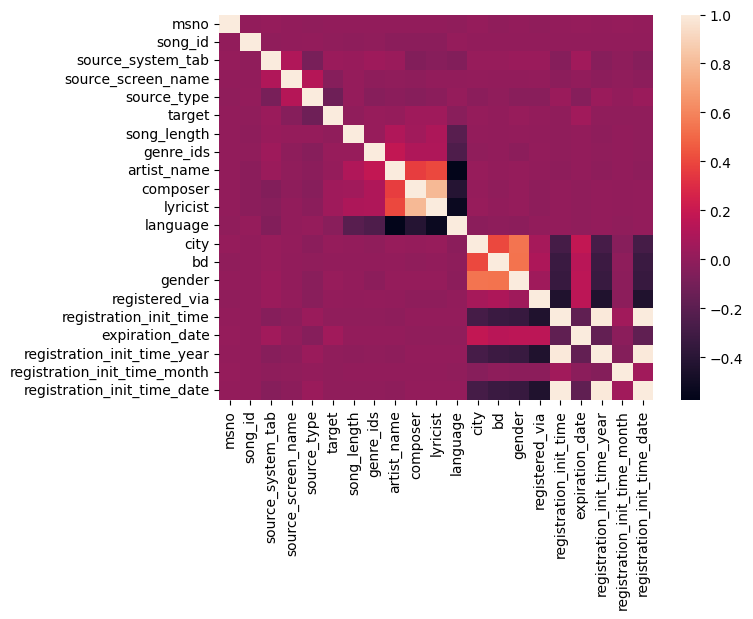

In [12]:
plt.figure(figsize=[7,5])
sns.heatmap(df.corr())
plt.show()

In [13]:
df = df.drop(['expiration_date', 'lyricist'], axis=1)

In [14]:
for i in df.select_dtypes(include=['object']).columns:
    df[i][df[i].isnull()] = 'unknown'
df = df.fillna(value=0)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 19 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   msno                          int16  
 1   song_id                       int32  
 2   source_system_tab             int8   
 3   source_screen_name            int8   
 4   source_type                   int8   
 5   target                        int64  
 6   song_length                   float64
 7   genre_ids                     int16  
 8   artist_name                   int32  
 9   composer                      int32  
 10  language                      float64
 11  city                          int64  
 12  bd                            int64  
 13  gender                        int8   
 14  registered_via                int64  
 15  registration_init_time        int16  
 16  registration_init_time_year   int32  
 17  registration_init_time_month  int32  
 18  registration_init_time_date   int

In [16]:
X = df.drop('target',axis=1).values
y = df['target'].values

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

df_DMatrix = xgb.DMatrix(data=X,label=y)

In [18]:
param_grid = {
    'max_depth': [3, 5, 7],
    'eta': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# The number of boosting rounds (or trees) XGBoost will add to the model.
num_boost_round = 100
# The number of rounds to wait before stopping if the model's performance doesn't improve
early_stopping_rounds = 10

# To Store results
results = []
best_params = {}
best_score = float('inf')

In [21]:
from sklearn.model_selection import RandomizedSearchCV

model = xgb.XGBClassifier(objective='binary:logistic',n_estimators=10,seed=123)

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_log_loss",
    cv=3,
    verbose=1,
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 0.8, 'max_depth': 7, 'eta': 0.2, 'colsample_bytree': 1.0}


In [22]:
model = xgb.XGBClassifier(**best_params)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [ ]:
preds = model.predict(X_test)

In [31]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.66      0.62      0.64    731405
           1       0.65      0.69      0.67    744079

    accuracy                           0.66   1475484
   macro avg       0.66      0.66      0.66   1475484
weighted avg       0.66      0.66      0.66   1475484



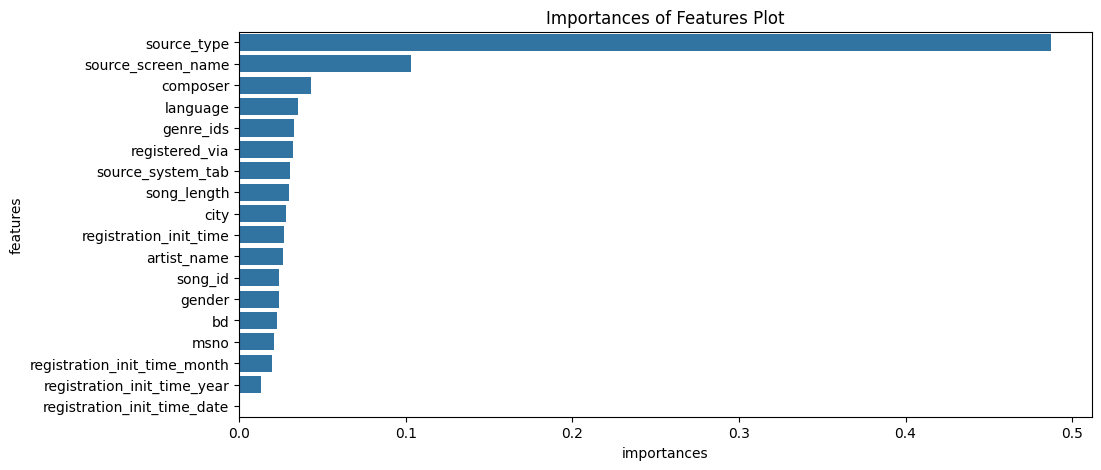

In [32]:
df_plot = pd.DataFrame({'features': df.columns[df.columns != 'target'],
                        'importances': model.feature_importances_})
df_plot = df_plot.sort_values('importances', ascending=False)
plt.figure(figsize=[11,5])
sns.barplot(x = df_plot.importances, y = df_plot.features)
plt.title('Importances of Features Plot')
plt.show()

In [36]:
import optuna
import xgboost as xgb

def objective(trial):

    params = {
        "objective": "multi:softmax",
        "num_class": 3,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "eta": trial.suggest_float("eta", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "eval_metric": "mlogloss",
        "nthread": -1
    }

    cv = xgb.cv(
        params,
        df_DMatrix,
        nfold=2,
        num_boost_round=4,
        early_stopping_rounds=2
    )

    return cv["test-mlogloss-mean"].min()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=4)

print(study.best_params)

[I 2026-04-08 01:01:12,415] A new study created in memory with name: no-name-3b76fae1-350f-4513-9576-3bf871a2582f
[I 2026-04-08 01:01:39,329] Trial 0 finished with value: 0.664520243206822 and parameters: {'max_depth': 6, 'eta': 0.1369104166180757, 'subsample': 0.8422278040828635, 'colsample_bytree': 0.6463171031131896}. Best is trial 0 with value: 0.664520243206822.
[I 2026-04-08 01:01:59,254] Trial 1 finished with value: 0.6760960356815242 and parameters: {'max_depth': 5, 'eta': 0.06802868266225409, 'subsample': 0.747623531851932, 'colsample_bytree': 0.6990425971954722}. Best is trial 0 with value: 0.664520243206822.
[I 2026-04-08 01:02:19,914] Trial 2 finished with value: 0.658522752321796 and parameters: {'max_depth': 6, 'eta': 0.19321344910377056, 'subsample': 0.6661756895947163, 'colsample_bytree': 0.7497283929344264}. Best is trial 2 with value: 0.658522752321796.
[I 2026-04-08 01:02:42,776] Trial 3 finished with value: 0.6741612391807938 and parameters: {'max_depth': 4, 'eta': 

{'max_depth': 6, 'eta': 0.19321344910377056, 'subsample': 0.6661756895947163, 'colsample_bytree': 0.7497283929344264}


In [41]:
model = xgb.XGBClassifier(**study.best_params)

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [42]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.66      0.62      0.64    731405
           1       0.64      0.68      0.66    744079

    accuracy                           0.65   1475484
   macro avg       0.65      0.65      0.65   1475484
weighted avg       0.65      0.65      0.65   1475484

